# Meteo: Shot-wave incoming radiation (SW_IN) (2005-2024)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Variable

In [1]:
varname = 'SW_IN_T1_2_1'
var = "SW_IN"  # Name shown in plots
units = r"($\mathrm{W\ m^{-2}}$)"

# Imports

In [2]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import diive as dv
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.bar import LongtermAnomaliesYear

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


# Load data

In [3]:
SOURCEDIR = r"../80_FINALIZE"
FILENAME = r"81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
df

Loaded .parquet file ..\80_FINALIZE\81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet (4.571 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-12,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-18,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-24,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-6,.SWC_GF1_0.15_1_gfXG_MEAN3H-12,.SWC_GF1_0.15_1_gfXG_MEAN3H-18,.SWC_GF1_0.15_1_gfXG_MEAN3H-24,.SWC_GF1_0.15_1_gfXG_MEAN3H-6,.TS_GF1_0.04_1_gfXG_MEAN3H-12,.TS_GF1_0.04_1_gfXG_MEAN3H-18,.TS_GF1_0.04_1_gfXG_MEAN3H-24,.TS_GF1_0.04_1_gfXG_MEAN3H-6,.TS_GF1_0.15_1_gfXG_MEAN3H-12,.TS_GF1_0.15_1_gfXG_MEAN3H-18,.TS_GF1_0.15_1_gfXG_MEAN3H-24,...,GPP_NT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF,GPP_DT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF_SD,GPP_DT_CUT_50_gfRF_SD,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.918553,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.917972,0.092682,0.0,0.079688,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.163001,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.190890,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.167042,0.092295,0.0,0.079361,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,0.0,0.0,0.0,0.0,52.229004,52.226300,52.226689,52.216796,3.458828,3.150402,3.115260,3.660897,4.335667,4.347764,4.385967,...,-0.334996,1.091028,0.0,0.265808,0.0,NaN,NaN,-9.097370,-7.880106,NaN,NaN,311.167160,-5.883538,0.0,0.0
2024-12-31 22:15:00,0.0,0.0,0.0,0.0,52.227858,52.227986,52.224528,52.214211,3.522570,3.187638,3.103440,3.643396,4.338551,4.342880,4.379524,...,-0.310533,1.078751,0.0,0.264327,0.0,NaN,NaN,-9.561669,-8.172388,NaN,NaN,310.079817,-6.269816,0.0,0.0
2024-12-31 22:45:00,0.0,0.0,0.0,0.0,52.226640,52.229837,52.222456,52.209876,3.578745,3.230037,3.095339,3.624025,4.343767,4.339440,4.372636,...,-0.225651,1.079759,0.0,0.264447,0.0,NaN,NaN,-10.138718,-8.527732,NaN,NaN,309.604987,-6.934394,0.0,0.0


In [4]:
series = df[varname].copy()
series

TIMESTAMP_MIDDLE
2005-01-01 00:15:00    0.0
2005-01-01 00:45:00    0.0
2005-01-01 01:15:00    0.0
2005-01-01 01:45:00    0.0
2005-01-01 02:15:00    0.0
                      ... 
2024-12-31 21:45:00    0.0
2024-12-31 22:15:00    0.0
2024-12-31 22:45:00    0.0
2024-12-31 23:15:00    0.0
2024-12-31 23:45:00    0.0
Freq: 30min, Name: SW_IN_T1_2_1, Length: 350640, dtype: float64

In [5]:
xlabel = f"{var} ({units})"
xlim = [series.min(), series.max()]

</br>

# Stats

## Overall mean

In [6]:
_yearly_avg = series.resample('YE').mean()
_overall_mean = _yearly_avg.mean()
_overall_sd = _yearly_avg.std()
print(f"Overall mean: {_overall_mean} +/- {_overall_sd}")

Overall mean: 142.26910305225957 +/- 7.808229266372441


## Yearly means

In [7]:
series.resample('YE').mean()

TIMESTAMP_MIDDLE
2005-12-31    134.355814
2006-12-31    135.666212
2007-12-31    141.067281
2008-12-31    137.163616
2009-12-31    141.385800
2010-12-31    131.517953
2011-12-31    144.907574
2012-12-31    142.896565
2013-12-31    135.253588
2014-12-31    140.598788
2015-12-31    146.086643
2016-12-31    134.401040
2017-12-31    145.192251
2018-12-31    149.279495
2019-12-31    147.125672
2020-12-31    153.846174
2021-12-31    146.021649
2022-12-31    161.463670
2023-12-31    147.160061
2024-12-31    129.992216
Freq: YE-DEC, Name: SW_IN_T1_2_1, dtype: float64

## Monthly averages

In [8]:
seriesdf = pd.DataFrame(series)
seriesdf['MONTH'] = seriesdf.index.month
seriesdf['YEAR'] = seriesdf.index.year
monthly_avg = seriesdf.groupby(['YEAR', 'MONTH'])[varname].mean().unstack()
monthly_avg

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2005,49.786290,80.487103,147.603943,169.844213,207.320116,267.234259,206.605063,168.406810,149.684341,83.978029,50.427216,28.897572
2006,41.368657,53.663377,124.637048,165.518261,193.451108,274.536643,280.006797,158.426413,149.527674,96.050795,54.316725,31.820919
2007,43.158046,75.131413,141.239700,247.140637,224.268807,230.481517,227.602793,180.012133,162.536687,89.089943,41.925751,27.639557
2008,51.156328,96.721799,130.864679,153.624506,238.389338,231.397902,241.488335,197.968448,130.336162,91.777790,51.266992,28.941676
2009,34.916571,77.407979,119.077912,208.811299,234.584434,248.263890,228.103889,224.333001,150.505691,91.399366,46.572884,29.319686
2010,37.782288,77.886631,128.393283,209.639992,162.501512,215.707829,247.335335,175.822384,156.474499,79.776834,50.595668,34.539569
2011,42.926370,76.388086,132.588952,240.700872,263.236178,207.338394,224.806449,229.281393,156.705108,90.845693,40.791743,28.776724
2012,38.304772,87.847401,173.175992,163.488935,246.859886,230.533297,222.306829,234.708784,140.542598,84.355612,48.579555,40.876400
2013,44.709167,74.858826,106.902927,150.719549,181.798196,228.230506,275.676735,227.173503,150.513363,85.428740,47.462954,44.882390


</br>

# Heatmap plots

## Half-hourly

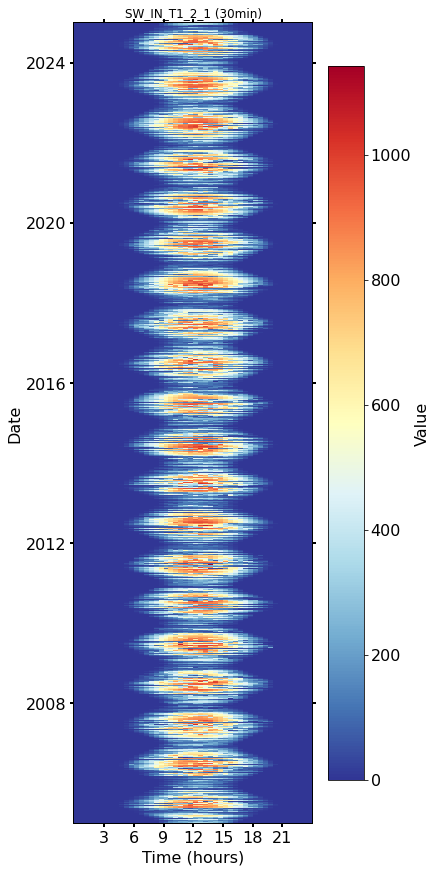

In [13]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
dv.heatmapdatetime(series=series, ax=axs, cb_digits_after_comma=0).plot()

## Monthly

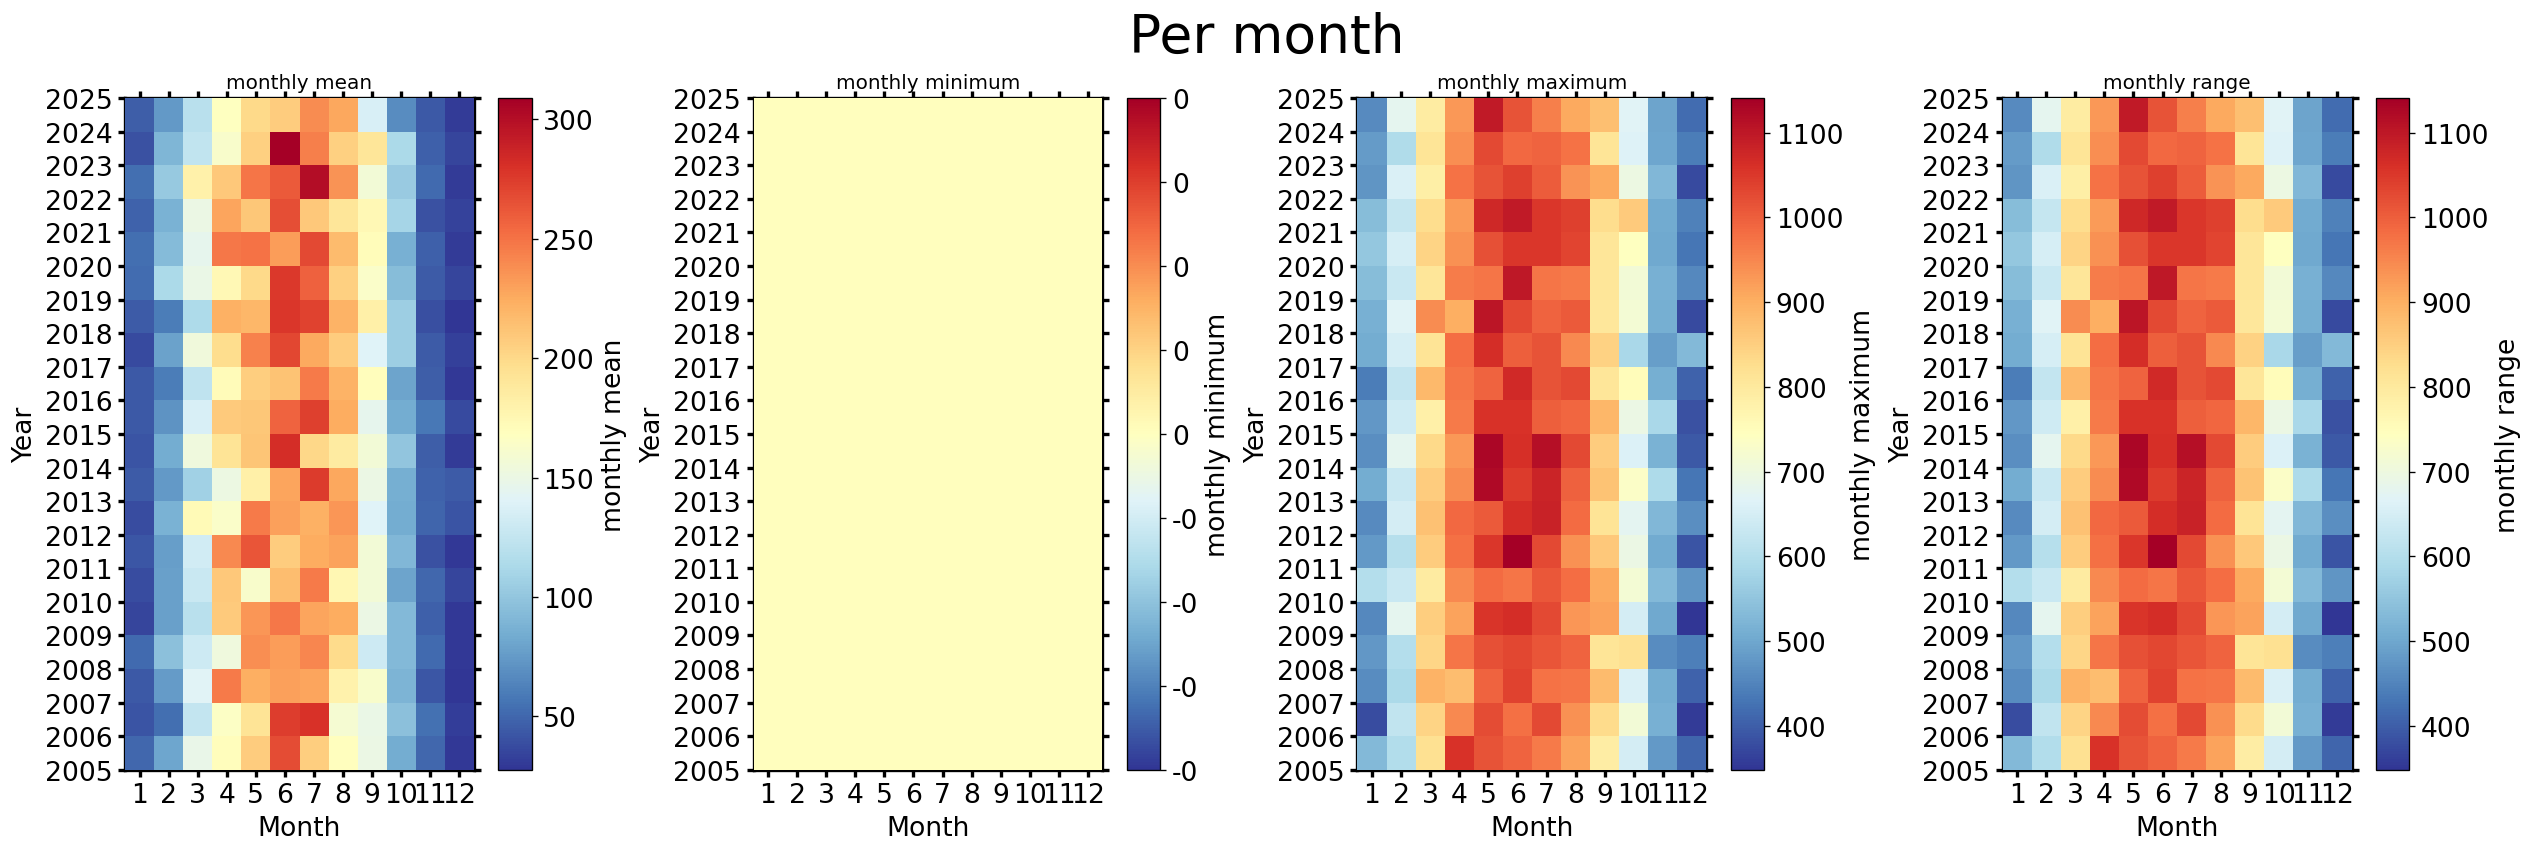

In [14]:
fig, axs = plt.subplots(ncols=4, figsize=(21, 7), dpi=120, layout="constrained")
fig.suptitle(f'Per month', fontsize=32)
dv.heatmapyearmonth(series_monthly=series.resample('M').mean(), title="monthly mean", ax=axs[0], cb_digits_after_comma=0, zlabel="monthly mean").plot()
dv.heatmapyearmonth(series_monthly=series.resample('M').min(), title="monthly minimum", ax=axs[1], cb_digits_after_comma=0, zlabel="monthly minimum").plot()
dv.heatmapyearmonth(series_monthly=series.resample('M').max(), title="monthly maximum", ax=axs[2], cb_digits_after_comma=0, zlabel="monthly maximum").plot()
_range = series.resample('M').max().sub(series.resample('M').min())
dv.heatmapyearmonth(series_monthly=_range, title="monthly range", ax=axs[3], cb_digits_after_comma=0, zlabel="monthly range").plot()

## Monthly ranks

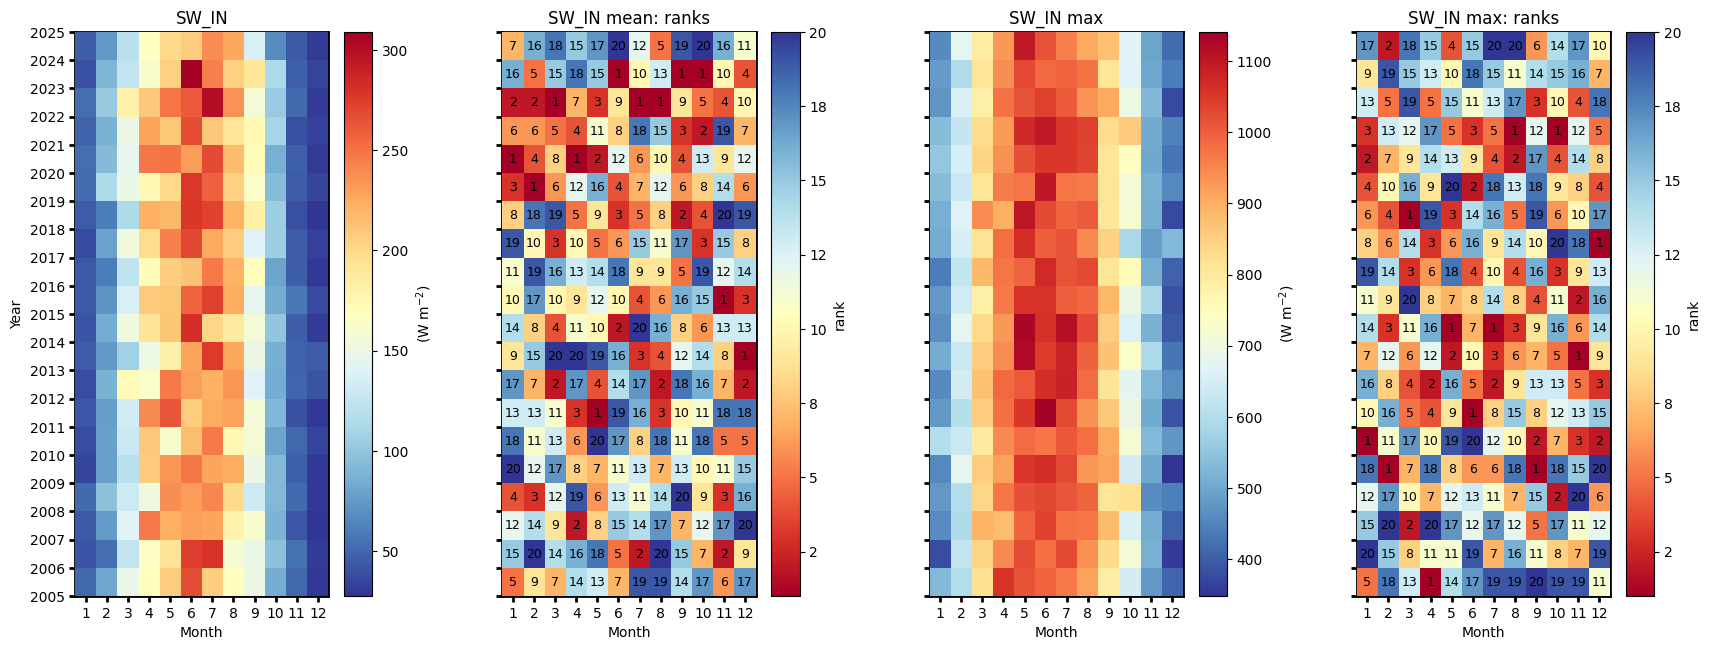

In [20]:
# Figure
fig = plt.figure(facecolor='white', figsize=(17, 6))

# Gridspec for layout
gs = gridspec.GridSpec(1, 4)  # rows, cols
gs.update(wspace=0.35, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean_ranks = fig.add_subplot(gs[0, 1])
ax_max = fig.add_subplot(gs[0, 2])
ax_max_ranks = fig.add_subplot(gs[0, 3])
params = {'axlabels_fontsize': 10, 'ticks_labelsize': 10, 'cb_labelsize': 10}
dv.heatmapyearmonth_ranks(ax=ax_mean, series=series, agg='mean', ranks=False, zlabel=f"{units}", cmap="RdYlBu_r", show_values=False, **params).plot()

hm_mean_ranks = dv.heatmapyearmonth_ranks(ax=ax_mean_ranks, series=series, agg='mean', **params)
hm_mean_ranks.plot()

dv.heatmapyearmonth_ranks(ax=ax_max, series=series, agg='max', ranks=False, zlabel=f"{units}", cmap="RdYlBu_r", show_values=False, **params).plot()
dv.heatmapyearmonth_ranks(ax=ax_max_ranks, series=series, agg='max', **params).plot()

ax_mean.set_title(f"{var}", color='black')
ax_mean_ranks.set_title(f"{var} mean: ranks", color='black')
ax_max.set_title(f"{var} max", color='black')
ax_max_ranks.set_title(f"{var} max: ranks", color='black')

ax_mean.tick_params(left=True, right=False, top=False, bottom=True,
                    labelleft=True, labelright=False, labeltop=False, labelbottom=True)
ax_mean_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                   labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)

ax_mean_ranks.set_ylabel("")
ax_max.set_ylabel("")
ax_max_ranks.set_ylabel("")

fig.show()

### Mean ranks per year

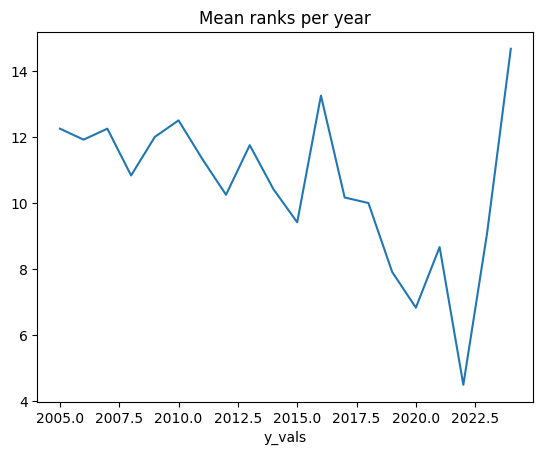

In [18]:
hm_mean_ranks.hm.get_plot_data().mean(axis=1).plot(title="Mean ranks per year");

</br>

# Ridgeline plots

## Yearly

In [25]:
# rp = dv.ridgeline(series=series)
# rp.plot(
#     how='yearly',
#     kd_kwargs=None,  # params from scikit KernelDensity as dict
#     xlim=xlim,  # min/max as list
#     ylim=[0, 0.01],  # min/max as list
#     hspace=-0.8,  # overlap between months
#     xlabel=f"{var} ({units})",
#     fig_width=5,
#     fig_height=9,
#     shade_percentile=0.5,
#     show_mean_line=False,
#     fig_title=f"{var} per year (2005-2024)",
#     fig_dpi=72,
#     showplot=True,
#     ascending=False
# )

## Monthly

In [26]:
# rp.plot(
#     how='monthly',
#     kd_kwargs=None,  # params from scikit KernelDensity as dict
#     xlim=xlim,  # min/max as list
#     ylim=[0, 0.01],  # min/max as list
#     hspace=-0.6,  # overlap between months
#     xlabel=f"{var} ({units})",
#     fig_width=4.5,
#     fig_height=8,
#     shade_percentile=0.5,
#     show_mean_line=False,
#     fig_title=f"{var} per month (2005-2024)",
#     fig_dpi=72,
#     showplot=True,
#     ascending=False
# )

## Weekly

In [27]:
# rp.plot(
#     how='weekly',
#     kd_kwargs=None,  # params from scikit KernelDensity as dict
#     xlim=xlim,  # min/max as list
#     ylim=[0, 0.15],  # min/max as list
#     hspace=-0.6,  # overlap
#     xlabel=f"{var} ({units})",
#     fig_width=6,
#     fig_height=16,
#     shade_percentile=0.5,
#     show_mean_line=False,
#     fig_title=f"{var} per week (2005-2024)",
#     fig_dpi=72,
#     showplot=True,
#     ascending=False
# )

## Single years per month

In [28]:
# uniq_years = series.index.year.unique()
# for uy in uniq_years:
#     series_yr = series.loc[series.index.year == uy].copy()
#     rp = dv.ridgeline(series=series_yr)
#     rp.plot(
#         how='monthly',
#         kd_kwargs=None,  # params from scikit KernelDensity as dict
#         xlim=xlim,  # min/max as list
#         ylim=[0, 0.18],  # min/max as list
#         hspace=-0.6,  # overlap
#         xlabel=f"{var} ({units})",
#         fig_width=6,
#         fig_height=7,
#         shade_percentile=0.5,
#         show_mean_line=False,
#         fig_title=f"{var} per month ({uy})",
#         fig_dpi=72,
#         showplot=True,
#         ascending=False
#     )

## Single years per week

In [29]:
# uniq_years = series.index.year.unique()
# for uy in uniq_years:
#     series_yr = series.loc[series.index.year == uy].copy()
#     rp = dv.ridgeline(series=series_yr)
#     rp.plot(
#         how='weekly',
#         kd_kwargs=None,  # params from scikit KernelDensity as dict
#         xlim=xlim,  # min/max as list
#         ylim=[0, 0.3],  # min/max as list
#         hspace=-0.8,  # overlap
#         xlabel=f"{var} ({units})",
#         fig_width=9,
#         fig_height=18,
#         shade_percentile=0.5,
#         show_mean_line=False,
#         fig_title=f"{var} per week ({uy})",
#         fig_dpi=72,
#         showplot=True,
#         ascending=False
#     )

</br>

# Cumulative plot

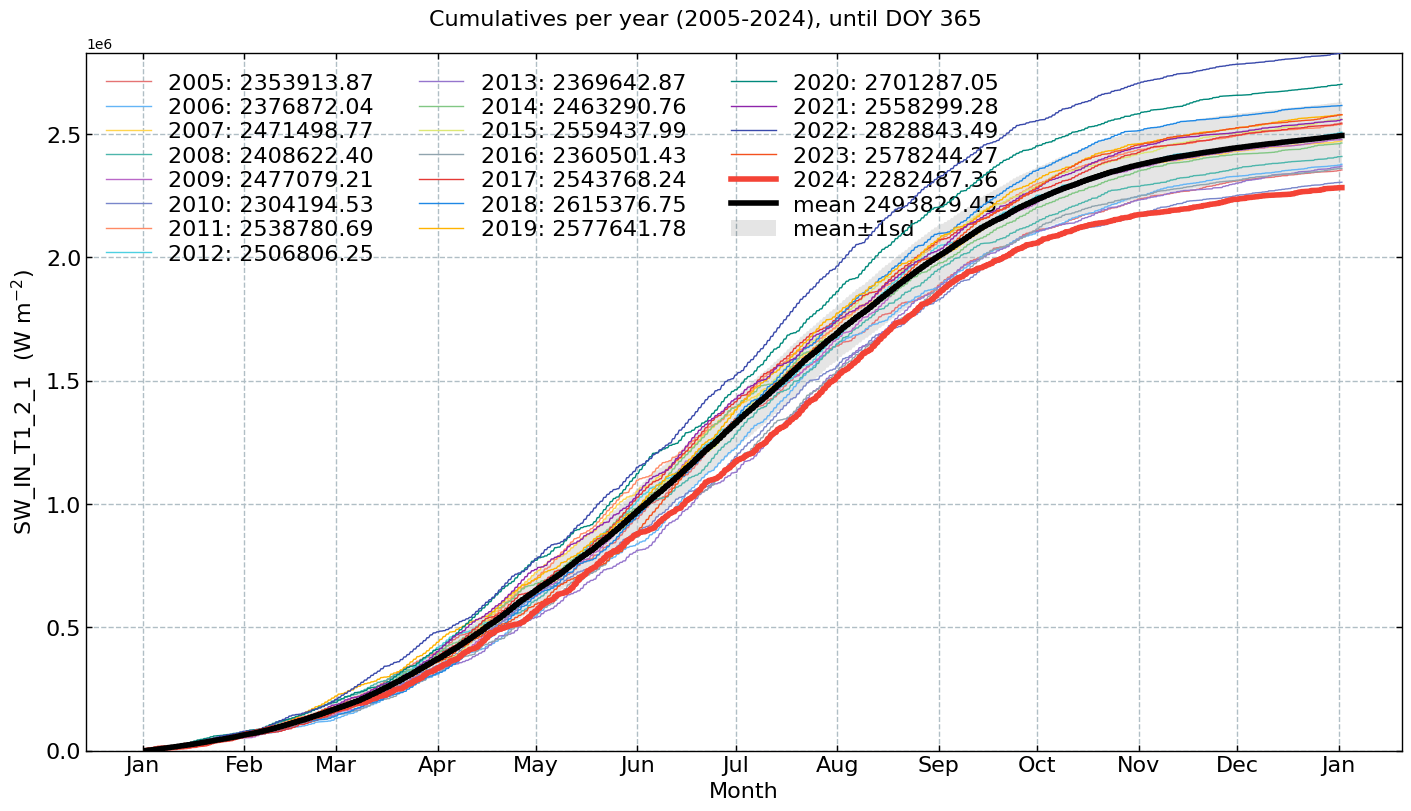

In [30]:
CumulativeYear(
    series=series,
    series_units=units,
    start_year=2005,
    end_year=2024,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=2024,
    highlight_year_color='#F44336').plot();

</br>

# Long-term anomalies

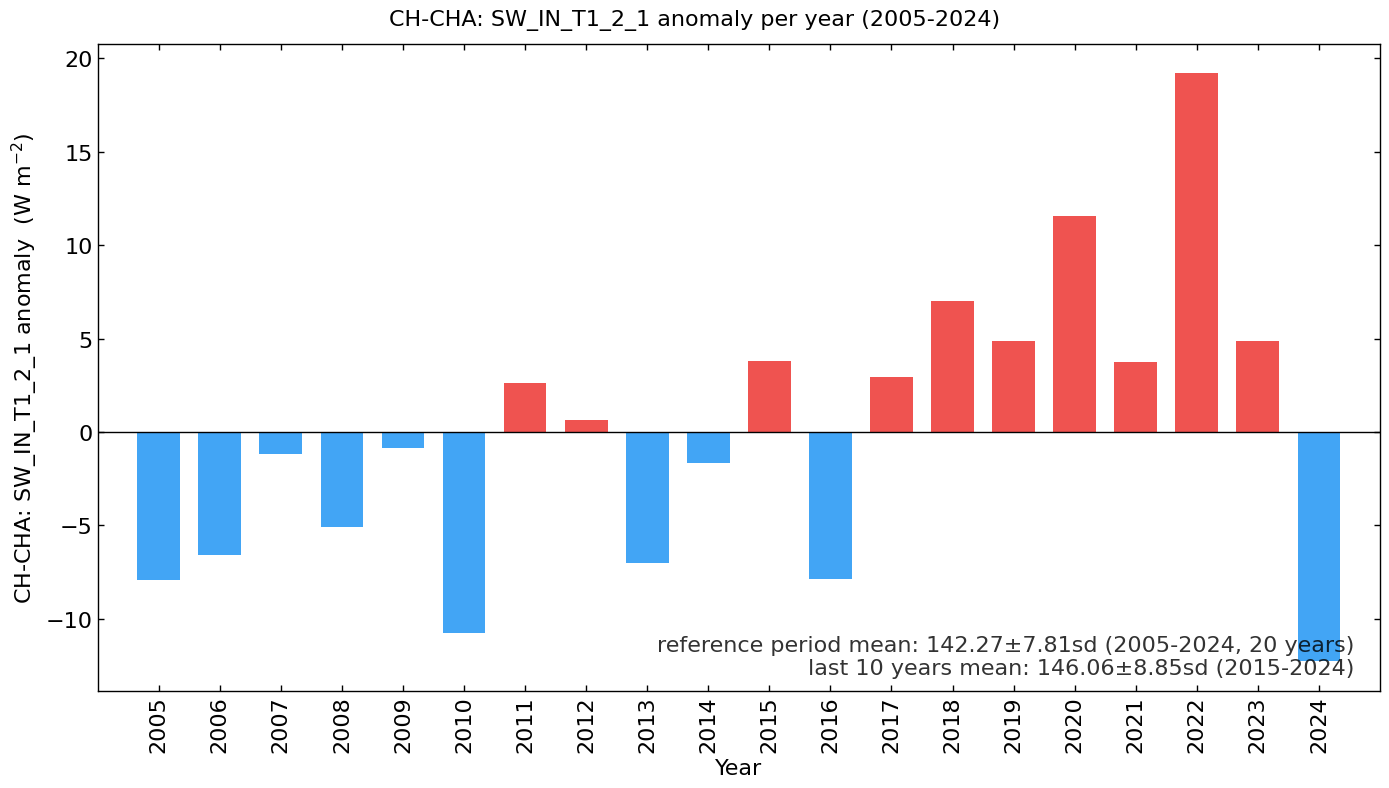

In [32]:
series_yearly_mean = series.resample('YE').mean()
series_yearly_mean.index = series_yearly_mean.index.year
series_label = f"CH-CHA: {varname}"
LongtermAnomaliesYear(series=series_yearly_mean,
                      series_label=series_label,
                      series_units=units,
                      reference_start_year=2005,
                      reference_end_year=2024).plot()

</br>

# End of notebook

In [33]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-05-16 12:49:51
